# Kwant — Theory and Practice · Chapter 12
## The 3D topological insulator, the exercises for Part II, and where to go next

*Part II · Sections 26–27 · Figures 66–68* &nbsp;·&nbsp; [← Chapter 11](11_Higher_Order_and_Weyl.ipynb) · [Contents](00_Contents.ipynb)

### In this chapter

- [26. The 3D topological insulator — a Dirac cone on every surface](#26.-The-3D-topological-insulator-—-a-Dirac-cone-on-every-surface)
- [Exercises for Part II](#Exercises-for-Part-II)
- [27. Where to go next](#27.-Where-to-go-next)
    - [The rest of the API](#The-rest-of-the-API)
    - [Ecosystem](#Ecosystem)
    - [Suggested exercises](#Suggested-exercises)
    - [Citing Kwant](#Citing-Kwant)
    - [A topological-matter reference shelf](#A-topological-matter-reference-shelf)
- [Sources, attribution and licence](#Sources,-attribution-and-licence)

**Exercises** E2.1–E2.14 are posed at the end of this chapter; the worked, asserted solutions are in [`S2_Solutions_Part_II.ipynb`](S2_Solutions_Part_II.ipynb).

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 66–68, so the counter starts at 65.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [65]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


---
## 26. The 3D topological insulator — a Dirac cone on every surface

The 3D strong TI [Fu, Kane & Mele, PRL **98**, 106803 (2007); realized in
Bi₂Se₃, Zhang *et al.*, Nat. Phys. **5**, 438 (2009)] is described near the
band inversion by the lattice-regularized Dirac model

$$H(\mathbf{k}) = m(\mathbf{k})\,\tau_z\!\otimes\!\sigma_0
 + \lambda\sum_{i=x,y,z}\sin k_i\ \tau_x\!\otimes\!\sigma_i,
 \qquad m(\mathbf{k}) = m_0 - t\!\sum_i \cos k_i .$$

With inversion symmetry ($P = \tau_z$) the strong $\mathbb{Z}_2$ index
follows from the **Fu–Kane parity criterion**: the product of the occupied
parity eigenvalues over the 8 time-reversal-invariant momenta,

$$(-1)^{\nu_0} = \prod_{\Lambda}\ \prod_{n \in \text{occ}} \xi_n(\Lambda).$$

For $1 < m_0/t < 3$ the band inversion happens at $\Gamma$ alone and
$\nu_0 = 1$.  The surface then *must* carry an odd number of Dirac cones —
a "half" graphene that cannot be gapped by any TRS-preserving perturbation.
Below: the parity count, the surface Dirac cone of a slab (with its
wavefunctions glued to the surfaces), and ballistic surface conduction
through the bulk gap of a 3D bar — absent in the trivial phase.

**Physics in more depth.**  The surface of a strong TI is a *single* Dirac
cone — half of graphene's — something impossible in any standalone 2D
lattice (fermion doubling).  Spin-momentum locking forbids 180°
backscattering, and a magnetic gap on the surface produces a half-integer
Hall response, the boundary face of bulk **axion electrodynamics**
[Qi, Hughes & Zhang, PRB **78**, 195424 (2008)].

*Experiments:* the parity criterion used below guided the first discovery
in Bi₁₋ₓSbₓ [Fu & Kane, PRB **76**, 045302 (2007); Hsieh *et al.*, Nature
**452**, 970 (2008)]; the "hydrogen-atom" TIs Bi₂Se₃/Bi₂Te₃ followed [Xia
*et al.*, Nat. Phys. **5**, 398 (2009); Zhang *et al.*, Nat. Phys. **5**,
438 (2009); Chen *et al.*, Science **325**, 178 (2009)].  Review: Ando,
J. Phys. Soc. Jpn. **82**, 102001 (2013).


m0 = 2.0:  Fu-Kane nu0 = 1   (strong TI)
m0 = 4.0:  Fu-Kane nu0 = 0   (trivial)


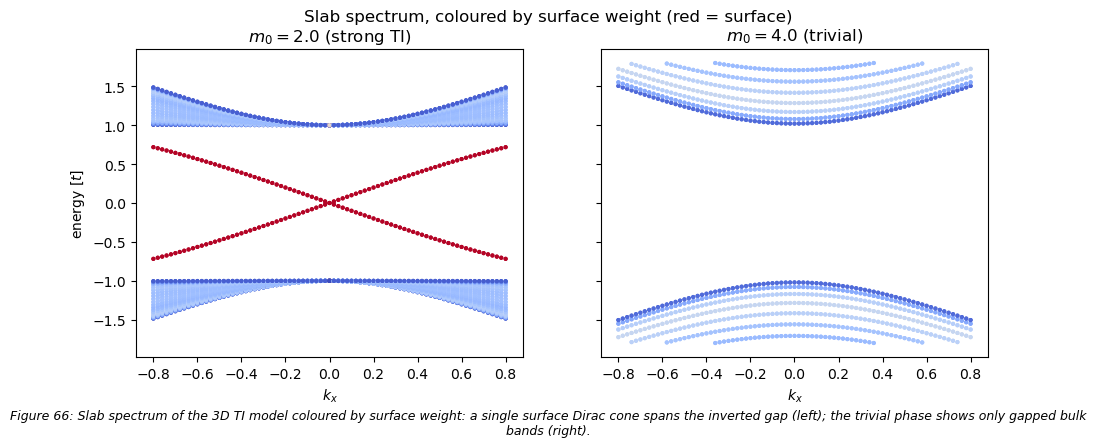

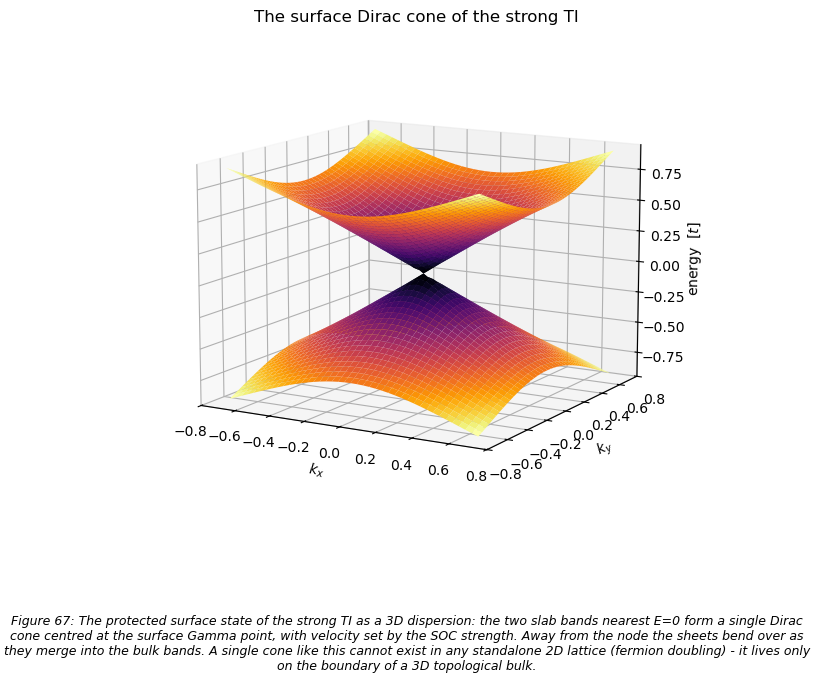

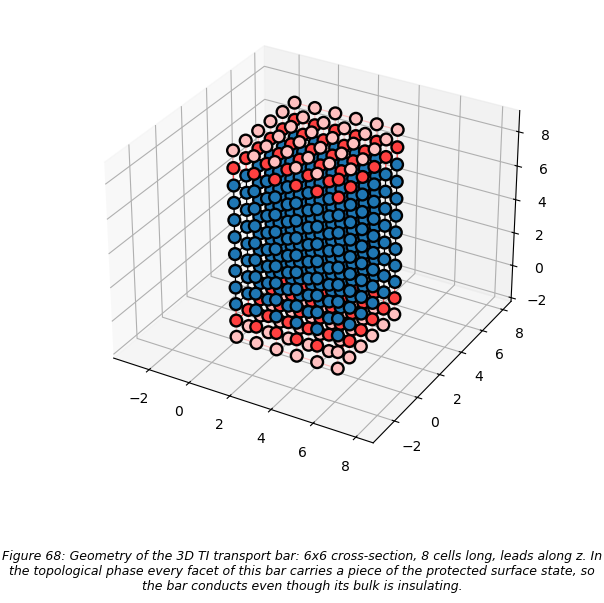

G(E=0.2) through a 3D bar:  TI = 2.000 e^2/h  (surface states);  trivial = 0.00e+00


In [2]:
# --- 3D TI: Fu-Kane parities, surface Dirac cone, surface transport -----------
import kwant, numpy as np
from itertools import product
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
k4 = np.kron

t, lam = 1.0, 1.0
G0, Gx, Gy, Gz = k4(sz, s0), k4(sx, sx), k4(sx, sy), k4(sx, sz)

def h_ti(kx, ky, kz, m0):
    m = m0 - t * (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return m * G0 + lam * (np.sin(kx) * Gx + np.sin(ky) * Gy + np.sin(kz) * Gz)

def fu_kane_nu0(m0):
    prod_par = 1.0
    for trim in product((0.0, np.pi), repeat=3):
        h = h_ti(*trim, m0)
        occ = np.linalg.eigh(h)[1][:, :2]
        par = np.linalg.eigvalsh(occ.conj().T @ G0 @ occ)   # inversion op = G0
        prod_par *= par[0]              # one representative per Kramers pair
    return 0 if prod_par > 0 else 1

for m0 in (2.0, 4.0):
    print(f"m0 = {m0}:  Fu-Kane nu0 = {fu_kane_nu0(m0)}"
          + ("   (strong TI)" if fu_kane_nu0(m0) else "   (trivial)"))

# slab: the surface Dirac cone, coloured by where the state lives
Nz = 20
hop_z = -t * G0 / 2 + lam * Gz / (2j)

def slab_h(kx, ky, m0):
    on = ((m0 - t * np.cos(kx) - t * np.cos(ky)) * G0
          + lam * (np.sin(kx) * Gx + np.sin(ky) * Gy))
    H = np.zeros((4 * Nz, 4 * Nz), dtype=complex)
    for z in range(Nz):
        H[4*z:4*z+4, 4*z:4*z+4] = on
        if z + 1 < Nz:
            H[4*z:4*z+4, 4*z+4:4*z+8] = hop_z
            H[4*z+4:4*z+8, 4*z:4*z+4] = hop_z.conj().T
    return H

kxs = np.linspace(-0.8, 0.8, 81)
fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m0, label in zip(axes, (2.0, 4.0), ("strong TI", "trivial")):
    for kx in kxs:
        ev, vec = np.linalg.eigh(slab_h(kx, 0, m0))
        sel = np.abs(ev) < 1.8            # wide enough to show bulk bands
        surf = (np.abs(vec[:, sel]) ** 2).reshape(Nz, 4, -1).sum(axis=1)
        w = surf[:3].sum(axis=0) + surf[-3:].sum(axis=0)
        ax.scatter([kx] * sel.sum(), ev[sel], c=w, s=4, cmap='coolwarm',
                   vmin=0, vmax=1)
    ax.set_title(f"$m_0 = {m0}$ ({label})"); ax.set_xlabel(r"$k_x$")
axes[0].set_ylabel("energy $[t]$")
fig.suptitle("Slab spectrum, coloured by surface weight (red = surface)")
show_fig(r'Slab spectrum of the 3D TI model coloured by surface weight: a single surface Dirac cone spans the inverted gap (left); the trivial phase shows only gapped bulk bands (right).')

# the surface Dirac cone itself, rendered in 3D: for each (kx, ky) take the
# two slab states closest to E = 0 (the upper and lower halves of the cone)
kr = np.linspace(-0.7, 0.7, 41)
KX, KY = np.meshgrid(kr, kr)
E_up = np.zeros_like(KX)
E_dn = np.zeros_like(KX)
for i in range(len(kr)):
    for j in range(len(kr)):
        ev_k = np.linalg.eigvalsh(slab_h(KX[i, j], KY[i, j], 2.0))
        E_up[i, j] = ev_k[ev_k > 0].min()
        E_dn[i, j] = ev_k[ev_k < 0].max()

fig = pyplot.figure(figsize=(8, 6.5))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(KX, KY, E_up, cmap='inferno', linewidth=0, antialiased=True)
ax.plot_surface(KX, KY, E_dn, cmap='inferno_r', linewidth=0, antialiased=True)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_zlabel('energy  $[t]$')
ax.set_title('The surface Dirac cone of the strong TI')
ax.view_init(elev=12, azim=-60)
show_fig(r'The protected surface state of the strong TI as a 3D dispersion: the two slab bands nearest E=0 form a single Dirac cone centred at the surface Gamma point, with velocity set by the SOC strength. Away from the node the sheets bend over as they merge into the bulk bands. A single cone like this cannot exist in any standalone 2D lattice (fermion doubling) - it lives only on the boundary of a 3D topological bulk.')

# transport: in-gap conductance carried by the surface, zero when trivial
lat3 = kwant.lattice.cubic(norbs=4)
hops = {(1, 0, 0): -t * G0 / 2 + lam * Gx / (2j),
        (0, 1, 0): -t * G0 / 2 + lam * Gy / (2j),
        (0, 0, 1): hop_z}

def ti_bar(m0, W=6, L=8):
    def fill(syst, rng):
        syst[(lat3(x, y, z) for x in range(W) for y in range(W) for z in rng)] \
            = m0 * G0
        for d, v in hops.items():
            syst[kwant.builder.HoppingKind(d, lat3, lat3)] = v
    syst = kwant.Builder()
    fill(syst, range(L))
    lead = kwant.Builder(kwant.TranslationalSymmetry((0, 0, -1)))
    fill(lead, [0])
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.2                                      # inside the bulk gap
fbar = ti_bar(2.0)
kwant.plot(fbar, site_size=0.25, hop_lw=0.05, fig_size=(6, 6), show=False)
show_fig(r'Geometry of the 3D TI transport bar: 6x6 cross-section, 8 cells long, leads along z. In the topological phase every facet of this bar carries a piece of the protected surface state, so the bar conducts even though its bulk is insulating.')
G_top = kwant.smatrix(fbar, E).transmission(1, 0)
G_tri = kwant.smatrix(ti_bar(4.0), E).transmission(1, 0)
print(f"G(E={E}) through a 3D bar:  TI = {G_top:.3f} e^2/h  "
      f"(surface states);  trivial = {G_tri:.2e}")
assert G_top > 1.0 and G_tri < 1e-6

---
## Exercises for Part II

Solutions in **`S2_Solutions_Part_II.ipynb`** (same folder).

**E2.1** ◦ *(after Asbóth, Oroszlány & Pályi, ch. 1)* — An SSH chain with an
*odd* number of sites hosts exactly one zero mode for any $t_1, t_2$.
Verify numerically, and determine on which sublattice it lives depending on
$t_1 \lessgtr t_2$.

**E2.2** • *(after Jackiw-Rebbi; Asbóth ch. 1)* — Build an SSH chain with a
domain wall in the middle ($t_1<t_2$ on the left, $t_1>t_2$ on the right).
Show a zero mode binds to the wall, plot it, and check its sublattice
polarisation.

**E2.3** ★ *(inspired by topocondmat.org, week 1)* — Add a next-nearest-
neighbour hopping $t'\,\tau_z$ to the Kitaev chain.  For large enough $t'$
the invariant (class BDI winding number) reaches $W=2$: two Majorana modes
per end.  Find such a parameter point numerically and show the doubled zero
modes survive chemical-potential disorder but not... which perturbation?

**E2.4** ◦ *(after topocondmat.org, week 2)* — Plot the height of the
nanowire zero-bias peak at fixed $B > B_c$ as a function of wire length and
show it approaches $2e^2/h$ exponentially (Majorana splitting).

**E2.5** ◦ *(original)* — Reverse the direction of the Rice-Mele pump cycle
and recompute the Chern number over $(k,\varphi)$; then deform the cycle so
it no longer encircles the origin and watch $C$ drop to zero.

**E2.6** ◦ *(original)* — Recompute the Haldane phase diagram at
$t_2 = 0.05$ and verify the lobe boundary rescales exactly as
$3\sqrt{3}\,t_2\sin\phi$.

**E2.7** • *(after topocondmat.org, week 4)* — Build a Haldane ribbon with
*armchair* edges and show the chiral edge mode still crosses the gap:
bulk-boundary correspondence does not care about the termination.

**E2.8** • *(after Kane & Mele, PRL 95, 226801 (2005))* — Sweep the
staggered mass $M$ in the Kane-Mele bar and locate the value where the
edge conductance $G=2e^2/h$ collapses; compare with the spin-Chern
transition at $M = 3\sqrt{3}\lambda_{SO}$.

**E2.9** ★ *(after Read & Green, PRB 61, 10267 (2000))* — Put a vortex in
the p+ip order parameter: $\Delta(\mathbf r) = \Delta\,e^{i\theta(\mathbf
r)}$ on a disc (implement the phase on the bond pairing terms).  Find the
near-zero mode bound to the core and check the core-state/edge-state energy
splitting shrinks with disc radius.

**E2.10** ◦ *(after Benalcazar-Bernevig-Hughes, Science 357, 61 (2017))* —
Add a small onsite perturbation $+\epsilon$ on sublattices 1,2 and
$-\epsilon$ on 3,4 of the BBH flake, breaking the protecting mirror
symmetries; show the four corner modes split away from zero linearly.

**E2.11** • *(original)* — Sweep $m_0$ in the Weyl model and track the two
nodes: show they migrate to the BZ boundary $k_z=\pi$ as $m_0 \to 3t$,
annihilate there, and that beyond this the slice Chern number vanishes for
all $k_z$ (a trivial insulator; for $1<m_0/t<3$... what happens at the
other end?).

**E2.12** ★ *(after Fu & Kane, PRB 76, 045302 (2007))* — For $m_0 = 0.5$
(band inversions at more than one TRIM) compute all four $\mathbb{Z}_2$
indices $(\nu_0; \nu_1\nu_2\nu_3)$ from the parities and identify the weak
topological phase; verify with slab spectra in two different orientations.

**E2.13** • *(original; cf. thin-film Bi₂Se₃, Zhang et al., Nat. Phys. 6,
584 (2010))* — Plot the surface-state gap of the 3D TI slab at
$\bar\Gamma$ vs thickness $N_z$ and extract the surface-state penetration
depth from the exponential decay.

**E2.14** ◦ *(pencil, original)* — From particle-hole symmetry alone, show
that any BdG eigenstate at $+E$ has a partner at $-E$, and that a
*single* level pinned at $E=0$ cannot be moved without breaking the
symmetry — the algebraic heart of Majorana protection.

---
## 27. Where to go next

### The rest of the API

| Module | Purpose |
|---|---|
| `kwant.physics` | `Bands`, `modes`, `PropagatingModes`, `StabilizedModes`, `magnetic_gauge`, `two_terminal_shotnoise` |
| `kwant.rmt` | random-matrix ensembles for all ten symmetry classes |
| `kwant.digest` | reproducible pseudo-random on-site disorder keyed by site — the right way to do disorder averaging |
| `kwant.wraparound` | fold a translationally symmetric `Builder` into a Brillouin-zone-parameterised one; how you get bulk band structures |
| `kwant.qsymm` | find and impose symmetries of a model (interface to the `qsymm` package) |
| `kwant.linalg.lll` | lattice reduction, used internally for lead construction |

### Ecosystem

- **TKwant** — time-dependent quantum transport; the natural extension for pulses, AC drive
  and quenches (released 2020).
- **Adaptive** — adaptive sampling of expensive functions. Pairs extremely well with
  parameter sweeps: it puts points where the curve is interesting rather than on a grid.
- **Qsymm** — symmetry finding and $k\cdot p$ model generation.
- **semicon**, **kwantspectrum**, and other community extensions listed on the project site.

### Suggested exercises

1. Add Anderson disorder to the § 3 wire (`kwant.digest.uniform` keyed on `site.tag`) and
   watch the plateaus wash out. Average over disorder realisations; extract the localisation
   length from $\ln T$ vs $L$.
2. Make a four-terminal Hall bar; compute $R_{xx}$ and $R_{xy}$ versus field and find the
   quantum Hall plateaus.
3. Build the Kitaev chain / Rashba-nanowire-with-superconductivity model and locate the
   zero-bias conductance peak as a function of Zeeman field.
4. Take the § 13 BHZ ribbon, add a magnetic field, and follow the edge states through the
   topological transition.
5. Use KPM to compute the DOS of a $10^6$-site disordered graphene sheet — infeasible by
   diagonalisation, routine by KPM.

### Citing Kwant

> C. W. Groth, M. Wimmer, A. R. Akhmerov, X. Waintal,
> *Kwant: a software package for quantum transport*,
> **New Journal of Physics 16, 063065 (2014)**.
> [doi:10.1088/1367-2630/16/6/063065](https://doi.org/10.1088/1367-2630/16/6/063065) —
> open access, [arXiv:1309.2926](https://arxiv.org/abs/1309.2926).

Kwant is free software (BSD-2-Clause), developed at CEA Grenoble, TU Delft and elsewhere.

---

*Sources: these notebooks were written against the Kwant 1.5 documentation mirrored in
`mirror/doc/` alongside it — tutorial sections 2.1–2.12, the `kwant.builder`,
`kwant.solvers`, `kwant.kpm`, `kwant.qsymm`, `kwant.system` and `kwant.physics` reference
pages, and the 1.5 release notes.*

### A topological-matter reference shelf

* **Foundations:** TKNN, PRL **49**, 405 (1982); Berry, Proc. R. Soc. A
  **392**, 45 (1984); Xiao, Chang & Niu, RMP **82**, 1959 (2010).
* **Reviews:** Hasan & Kane, RMP **82**, 3045 (2010); Qi & Zhang, RMP
  **83**, 1057 (2011); Chiu *et al.*, RMP **88**, 035005 (2016)
  (classification); Armitage *et al.*, RMP **90**, 015001 (2018)
  (semimetals); Sato & Ando, Rep. Prog. Phys. **80**, 076501 (2017)
  (superconductors); Xie *et al.*, Nat. Rev. Phys. **3**, 520 (2021)
  (higher-order).
* **Books:** Bernevig & Hughes, *Topological Insulators and Topological
  Superconductors* (Princeton, 2013); Asbóth, Oroszlány & Pályi, *A Short
  Course on Topological Insulators* (Springer, 2016); Vanderbilt, *Berry
  Phases in Electronic Structure Theory* (Cambridge, 2018).
* **Courses with code:** [topocondmat.org](https://topocondmat.org) (Kwant
  based, like this notebook); the
  [PythTB examples](https://www.physics.rutgers.edu/pythtb/examples.html).


---
## Sources, attribution and licence

The chapter notebooks of this course and their two solutions notebooks are released
under the **Apache License 2.0** (see `LICENSE` in the repository). The code, text,
figures and exercises are original unless an item says otherwise. Three
sources were used as models and are credited where they are used:

| Source | What was taken | Licence of the source |
|---|---|---|
| **Kwant documentation and tutorial**, C. W. Groth *et al.*, kwant-project.org/doc/1 | API conventions; exercises E1.1, E1.2, E1.4 are re-posed tutorial problems (marked *from the Kwant tutorial*) | BSD 2-clause (`LICENSE.rst` of the Kwant distribution) |
| **topocondmat.org** — *Topology in Condensed Matter: Tying Quantum Knots*, TU Delft (A. R. Akhmerov *et al.*) | the pedagogical route through Part II; exercises E2.3, E2.4, E2.7 are paraphrased (marked *after / inspired by topocondmat.org*); no text or code is reproduced verbatim | course text CC BY-SA 4.0, code BSD 3-clause |
| **A Short Course on Topological Insulators**, J. K. Asbóth, L. Oroszlány, A. Pályi (Springer 2016; arXiv:1509.02295) | the SSH/Kitaev presentation; exercises E2.1, E2.2 are paraphrased (marked *after Asbóth*) | book, © Springer; arXiv version CC BY 4.0 |

**How to cite this notebook.** See `CITATION.cff` in the repository.

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.
